<a href="https://colab.research.google.com/github/vodnalasuhas/DAA-CSE-C/blob/main/EXP5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

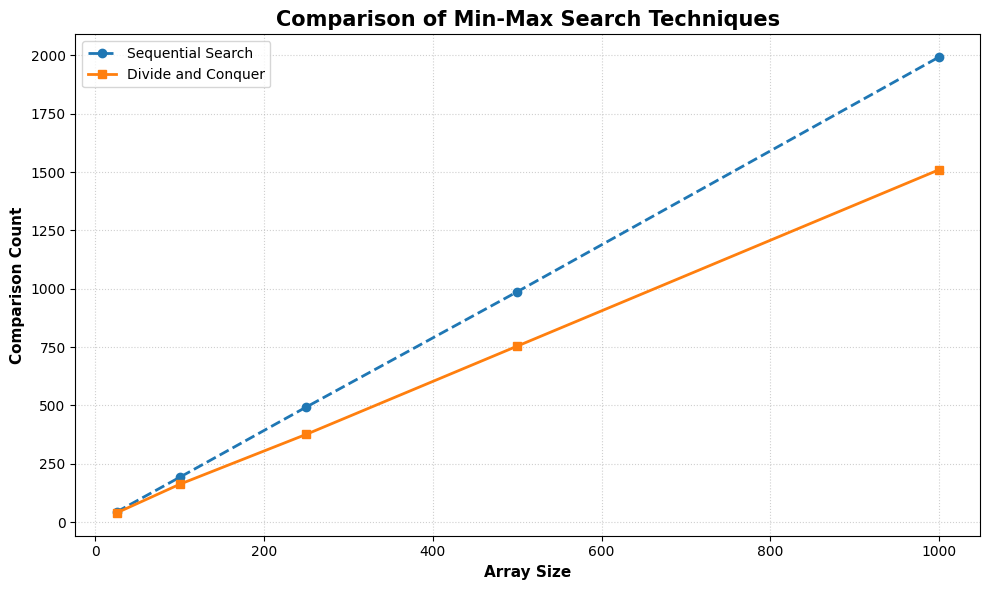

In [6]:
import random
import matplotlib.pyplot as plt

# -------------------- Divide and Conquer --------------------

def min_max_dc(data, start, end):

    if start == end:
        return data[start], data[start], 0

    if end - start == 1:

        if data[start] <= data[end]:
            return data[start], data[end], 1
        else:
            return data[end], data[start], 1

    mid = (start + end) // 2

    left_min, left_max, left_count = min_max_dc(data, start, mid)
    right_min, right_max, right_count = min_max_dc(data, mid + 1, end)

    smallest = left_min if left_min < right_min else right_min
    largest = left_max if left_max > right_max else right_max

    comparisons = left_count + right_count + 2

    return smallest, largest, comparisons


# -------------------- Sequential Method --------------------

def min_max_scan(data):

    low = high = data[0]
    count = 0

    for item in data[1:]:

        count += 1

        if item < low:
            low = item

        else:
            count += 1

            if item > high:
                high = item

    return low, high, count


# -------------------- Performance Test --------------------

sizes = [25, 100, 250, 500, 1000]

scan_counts = []
dc_counts = []

for n in sizes:

    values = [random.randint(1, 100000) for _ in range(n)]

    _, _, scan = min_max_scan(values)
    _, _, divide = min_max_dc(values, 0, len(values) - 1)

    scan_counts.append(scan)
    dc_counts.append(divide)


# -------------------- Plot --------------------

plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    scan_counts,
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Sequential Search"
)

plt.plot(
    sizes,
    dc_counts,
    marker="s",
    linewidth=2,
    linestyle="-",
    label="Divide and Conquer"
)

plt.title(
    "Comparison of Min-Max Search Techniques",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Array Size",
    fontsize=11,
    fontweight="bold"
)

plt.ylabel(
    "Comparison Count",
    fontsize=11,
    fontweight="bold"
)

plt.grid(True, linestyle=":", alpha=0.6)

plt.legend()

plt.tight_layout()
plt.show()